In [1]:
from pathlib import Path

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

In [2]:
PROJECT_ROOT = Path.cwd()

# Если ноутбук открыт из папки notebooks/, поднимаемся в корень проекта
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
OUTPUTS = PROJECT_ROOT / "outputs"
ANNOTATIONS_DIR = OUTPUTS / "annotations"
FIGURES_DIR = OUTPUTS / "figures"

for folder in [DATA_RAW, ANNOTATIONS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", DATA_RAW)
print("Outputs folder:", OUTPUTS)

Project root: /Users/user/Documents/emg-lr-segmentation
Raw data folder: /Users/user/Documents/emg-lr-segmentation/data/raw
Outputs folder: /Users/user/Documents/emg-lr-segmentation/outputs


In [3]:
fif_path = DATA_RAW / "3_3_rhythm_late_responses_raw.fif"

assert fif_path.exists(), f"Файл не найден: {fif_path}"

raw = mne.io.read_raw_fif(fif_path, preload=True)
raw_original = raw.copy()
raw_work = raw.copy()

print(raw)
print(raw.ch_names)
print("sfreq:", raw.info["sfreq"])

Opening raw data file /Users/user/Documents/emg-lr-segmentation/data/raw/3_3_rhythm_late_responses_raw.fif...
Isotrak not found
    Range : 0 ... 164899 =      0.000 ...    41.225 secs
Ready.
Reading 0 ... 164899  =      0.000 ...    41.225 secs...
<Raw | 3_3_rhythm_late_responses_raw.fif, 7 x 164900 (41.2 s), ~8.8 MiB, data loaded>
['EMG1', 'EMG2', 'EMG3', 'EMG4', 'EMG5', 'EMG6', 'EMG7']
sfreq: 4000.0


In [4]:
raw.plot(duration=10, n_channels=16)

Using qt as 2D backend.


Channels marked as bad:
none


In [5]:
# Авторазметка всех стимулов по каналу EMG7 

stim_ch = "EMG7"
stim_label = "Stimulus_Auto"

assert stim_ch in raw.ch_names, f"Канал {stim_ch} не найден. Доступные каналы: {raw.ch_names}"

sfreq = raw.info["sfreq"]

# 1. Берем Art
art_data, art_times = raw.copy().pick([stim_ch]).get_data(return_times=True)
art = art_data[0]

# 2. Центрируем и берём модуль: стимул на EMG7 может быть положительным или отрицательным
art_centered = art - np.median(art)
art_abs = np.abs(art_centered)

# 3. Robust threshold через MAD
art_abs_median = np.median(art_abs)
art_abs_mad = 1.4826 * np.median(np.abs(art_abs - art_abs_median))

peak_threshold = art_abs_median + 8.0 * art_abs_mad

# Минимальная дистанция между стимулами.
# Для ритма около 33 ms ставим 25 ms
stim_min_distance_ms = 25.0
stim_min_distance_samples = int(round(stim_min_distance_ms / 1000 * sfreq))

# 4. Ищем кандидаты стимулов
stim_samples, props = find_peaks(
    art_abs,
    height=peak_threshold,
    distance=stim_min_distance_samples,
)

if len(stim_samples) == 0:
    raise RuntimeError(
        "Не найдено ни одного стимула на Art. "
        "Проверь stim_ch, peak_threshold или визуально канал Art."
    )

stim_onsets = stim_samples / sfreq

print(f"Найдено Stimulus_Auto: {len(stim_samples)}")
print(f"Threshold Art abs: {peak_threshold:.3e}")

# 5. Проверяем ISI
isi_ms = np.diff(stim_samples) / sfreq * 1000

print("ISI median, ms:", np.median(isi_ms))
print("ISI mean, ms:", np.mean(isi_ms))
print("ISI min/max, ms:", np.min(isi_ms), np.max(isi_ms))
print("ISI 1/99 percentiles, ms:", np.percentile(isi_ms, [1, 99]))

# 6. Удаляем только старые Stimulus_Auto
old_ann = raw.annotations

keep_mask = np.array(old_ann.description) != stim_label

clean_annotations = mne.Annotations(
    onset=np.array(old_ann.onset)[keep_mask],
    duration=np.array(old_ann.duration)[keep_mask],
    description=np.array(old_ann.description)[keep_mask],
    orig_time=old_ann.orig_time,
)

# 7. Добавляем новые автостимулы
auto_stim_annotations = mne.Annotations(
    onset=stim_onsets,
    duration=np.zeros(len(stim_onsets)),
    description=[stim_label] * len(stim_onsets),
    orig_time=old_ann.orig_time,
)

raw.set_annotations(clean_annotations + auto_stim_annotations)

print(raw.annotations)
print("Stimulus_Auto count:", np.sum(raw.annotations.description == stim_label))

Найдено Stimulus_Auto: 1247
Threshold Art abs: 8.797e-07
ISI median, ms: 33.0
ISI mean, ms: 33.05477528089887
ISI min/max, ms: 27.25 38.75
ISI 1/99 percentiles, ms: [33.   33.25]
<Annotations | 1247 segments: Stimulus_Auto (1247)>
Stimulus_Auto count: 1247


Used Annotations descriptions: ['Stimulus_Auto']


n stimuli: 1247
ISI median, ms: 33.0
ISI mean, ms: 33.05477528089887
ISI std, ms: 0.3527853933639948
ISI min/max, ms: 27.25 38.75
ISI 1/99 percentiles, ms: [33.   33.25]


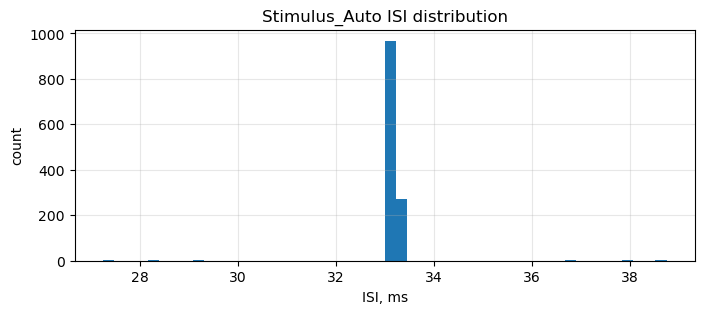

In [6]:
events_auto, event_id_auto = mne.events_from_annotations(
    raw,
    regexp="Stimulus_Auto"
)

stim_id_auto = event_id_auto["Stimulus_Auto"]

stim_samples_auto = events_auto[
    events_auto[:, 2] == stim_id_auto
][:, 0]

isi_ms = np.diff(stim_samples_auto) / raw.info["sfreq"] * 1000

print("n stimuli:", len(stim_samples_auto))
print("ISI median, ms:", np.median(isi_ms))
print("ISI mean, ms:", np.mean(isi_ms))
print("ISI std, ms:", np.std(isi_ms))
print("ISI min/max, ms:", np.min(isi_ms), np.max(isi_ms))
print("ISI 1/99 percentiles, ms:", np.percentile(isi_ms, [1, 99]))

plt.figure(figsize=(8, 3))
plt.hist(isi_ms, bins=50)
plt.xlabel("ISI, ms")
plt.ylabel("count")
plt.title("Stimulus_Auto ISI distribution")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Нарезка эпох по Stimulus_Auto с фильтром по корректному ISI

stim_label = "Stimulus_Auto"

# Окно эпохи
tmin = -0.005   # -5 ms baseline до стимула
tmax = 0.033    # ~33 ms до следующего стимула

# Берём только события Stimulus_Auto
events_auto, event_id_auto = mne.events_from_annotations(
    raw,
    regexp=stim_label
)

stim_id_auto = event_id_auto[stim_label]
stim_events = events_auto[events_auto[:, 2] == stim_id_auto]

stim_samples_auto = stim_events[:, 0]
isi_ms = np.diff(stim_samples_auto) / raw.info["sfreq"] * 1000

# Фильтр: оставляем стимулы, у которых следующий стимул через нормальный ISI
expected_isi_ms = np.median(isi_ms)
isi_tolerance_ms = 1.5

valid_isi_mask = np.abs(isi_ms - expected_isi_ms) <= isi_tolerance_ms

# Последний стимул не может дать полноценную эпоху до следующего стимула
valid_events = stim_events[:-1][valid_isi_mask]

epochs_metadata = pd.DataFrame({
    "epoch_index": np.arange(len(valid_events)),
    "stim_sample": valid_events[:, 0],
    "next_stim_sample": stim_samples_auto[1:][valid_isi_mask],
    "stim_time_s": valid_events[:, 0] / raw.info["sfreq"],
    "isi_ms": isi_ms[valid_isi_mask],
})

epochs_auto = mne.Epochs(
    raw_original,
    events=valid_events,
    event_id={stim_label: stim_id_auto},
    tmin=tmin,
    tmax=tmax,
    baseline=None,
    preload=True,
    reject_by_annotation=False,
    metadata=epochs_metadata,
)

print(epochs_auto)
print("Original stimuli:", len(stim_samples_auto))
print("Valid epochs:", len(epochs_auto))
print("Dropped by ISI filter:", np.sum(~valid_isi_mask))
print("Epoch data shape:", epochs_auto.get_data().shape)
print("Epoch time range, ms:", epochs_auto.times[0] * 1000, "to", epochs_auto.times[-1] * 1000)

display(epochs_auto.metadata.head())

Used Annotations descriptions: ['Stimulus_Auto']
Adding metadata with 5 columns
1240 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1240 events and 153 original time points ...
0 bad epochs dropped
<Epochs | 1240 events (all good), -0.005 – 0.033 s (baseline off), ~10.1 MiB, data loaded, with metadata,
 'Stimulus_Auto': 1240>
Original stimuli: 1247
Valid epochs: 1240
Dropped by ISI filter: 6
Epoch data shape: (1240, 7, 153)
Epoch time range, ms: -5.0 to 33.0


,epoch_index,stim_sample,next_stim_sample,stim_time_s,isi_ms
0,0,43,175,0.01075,33.00
1,1,175,308,0.04375,33.25
2,2,308,440,0.07700,33.00
3,3,440,572,0.11000,33.00
4,4,572,704,0.14300,33.00


In [10]:
# Подготовка данных выбранного EMG-канала для дальнейшего анализа

ch_name = "EMG3"  # поменять, если анализируешь другой канал

assert ch_name in epochs_auto.ch_names, (
    f"Канал {ch_name!r} не найден в epochs_auto. "
    f"Доступные каналы: {epochs_auto.ch_names}"
)

# Данные выбранного канала: epochs × time
epochs_data_uv = epochs_auto.get_data(picks=[ch_name])[:, 0, :] * 1e6
times_ms = epochs_auto.times * 1000

# Metadata отдельно, чтобы дальше добавлять туда результаты ER/LR
epochs_meta = epochs_auto.metadata.copy().reset_index(drop=True)

print("Analysis channel:", ch_name)
print("epochs_data_uv shape:", epochs_data_uv.shape)
print("times_ms range:", times_ms[0], "to", times_ms[-1])
print("metadata shape:", epochs_meta.shape)

display(epochs_meta.head())

Analysis channel: EMG3
epochs_data_uv shape: (1240, 153)
times_ms range: -5.0 to 33.0
metadata shape: (1240, 5)


,epoch_index,stim_sample,next_stim_sample,stim_time_s,isi_ms
0,0,43,175,0.01075,33.00
1,1,175,308,0.04375,33.25
2,2,308,440,0.07700,33.00
3,3,440,572,0.11000,33.00
4,4,572,704,0.14300,33.00


Baseline samples: 17
Baseline window, ms: -5.0 to -1.0


,baseline_median_uv,baseline_noise_uv
count,1240.000000,1240.000000
mean,-18.668466,49.401419
std,247.365047,36.386414
min,-960.226054,3.991659
25%,-190.057886,20.443280
50%,-42.979585,39.106003
75%,128.652937,67.585225
max,1022.476936,227.556756


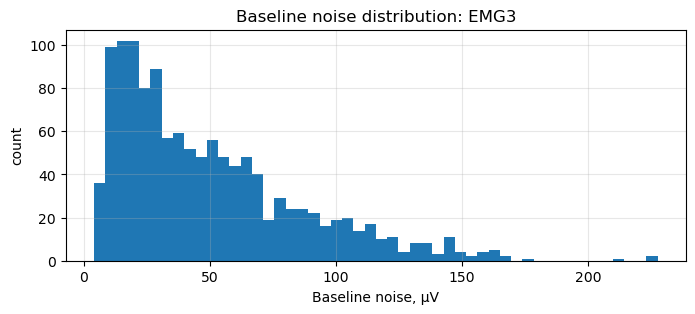

In [11]:
# Baseline noise для каждой эпохи

baseline_window_ms = (-5.0, -1.0)

baseline_mask = (
    (times_ms >= baseline_window_ms[0]) &
    (times_ms <= baseline_window_ms[1])
)

assert baseline_mask.sum() > 0, "Baseline window не попал во временную ось epochs_auto."

baseline_data = epochs_data_uv[:, baseline_mask]

# Медианный baseline каждой эпохи
baseline_median_uv = np.median(baseline_data, axis=1)

# Robust noise через MAD для каждой эпохи
baseline_noise_uv = 1.4826 * np.median(
    np.abs(baseline_data - baseline_median_uv[:, None]),
    axis=1
)

baseline_df = epochs_meta.copy()
baseline_df["baseline_median_uv"] = baseline_median_uv
baseline_df["baseline_noise_uv"] = baseline_noise_uv

print("Baseline samples:", baseline_mask.sum())
print("Baseline window, ms:", times_ms[baseline_mask][0], "to", times_ms[baseline_mask][-1])

display(
    baseline_df[["baseline_median_uv", "baseline_noise_uv"]].describe()
)

plt.figure(figsize=(8, 3))
plt.hist(baseline_noise_uv, bins=50)
plt.xlabel("Baseline noise, µV")
plt.ylabel("count")
plt.title(f"Baseline noise distribution: {ch_name}")
plt.grid(True, alpha=0.3)
plt.show()

Total epochs: 1240
Epochs with valid ER: 1235
Epochs without valid ER: 5
Global baseline noise, µV: 39.11
ER window, ms: (5.0, 10.5)
ER min absolute threshold, µV: 80.0

ER detection source:


,source,n
0,first_negative_peak,1230
1,deepest_minimum,5



ER summary:


,er_peak_ms,er_depth_uv,er_p2p_uv,baseline_noise_uv,er_depth_threshold_uv,er_depth_noise_ratio,er_p2p_noise_ratio
count,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000
mean,7.319231,1459.992489,1885.247739,49.428626,137.507661,50.184485,62.479919
std,0.542524,631.467314,1012.676946,36.393424,79.182194,49.799732,64.488398
min,6.250000,124.687509,94.374996,3.991659,80.000000,3.140811,3.847093
25%,7.000000,1012.415189,1152.173925,20.424098,80.000000,18.822996,24.537932
50%,7.250000,1410.444616,1737.527464,39.120874,97.802184,33.317327,41.097745
75%,7.500000,1839.816148,2451.161756,67.620483,169.051209,63.572383,77.651057
max,10.500000,3410.749956,5934.246350,227.556756,568.891889,523.910860,600.880069



Updated annotations:
Stimulus_Auto: 1247
ER_auto: 1235


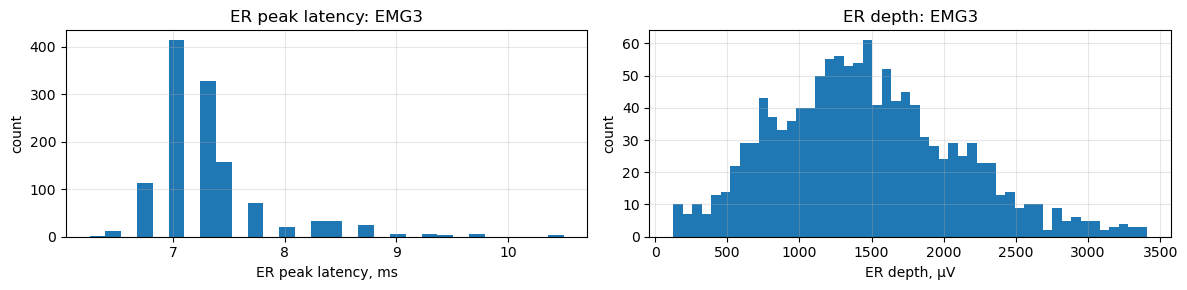

Channels marked as bad:
none


In [12]:
# ER detection + фильтр эпох по наличию валидного ER + пересоздание ER_auto

from scipy.signal import find_peaks

# -----------------------------
# Параметры ER detection
# -----------------------------

er_window_ms = (5.0, 10.5)   # шире текущего 6–10 ms, чтобы не пропускать смещённые ER

ER_LOCAL_NOISE_K = 2.5       # ER должен быть выше шума своей эпохи
ER_GLOBAL_NOISE_K = 2.0      # ER должен быть выше типичного шума записи
ER_MIN_ABS_UV = 80.0         # защита от разметки микрошума как ER

ER_PROM_NOISE_K = 1.5        # prominence относительно локального шума
ER_BOUNDARY_FRAC = 0.20      # границы ER на уровне 20% от глубины пика

ER_LABEL = "ER_auto"

assert "raw" in globals(), "Нужен raw"
assert "raw_original" in globals(), "Нужен raw_original"
assert "epochs_auto" in globals(), "Нужен epochs_auto"
assert "epochs_data_uv" in globals(), "Нужен epochs_data_uv"
assert "times_ms" in globals(), "Нужен times_ms"
assert "baseline_df" in globals(), "Нужен baseline_df"

# -----------------------------
# Подготовка окон и глобального шума
# -----------------------------

er_mask = (times_ms >= er_window_ms[0]) & (times_ms <= er_window_ms[1])
assert er_mask.sum() > 0, "ER window не попал во временную ось epochs_auto."

er_indices = np.where(er_mask)[0]

baseline_noise_all = pd.to_numeric(
    baseline_df["baseline_noise_uv"],
    errors="coerce"
).to_numpy()

global_noise_uv = np.nanmedian(baseline_noise_all)

dt_ms = np.median(np.diff(times_ms))
min_peak_distance_samples = max(1, int(round(0.8 / dt_ms)))

# -----------------------------
# ER detection
# -----------------------------

er_records = []

for epoch_idx in range(epochs_data_uv.shape[0]):
    signal_uv = epochs_data_uv[epoch_idx].copy()

    base_row = baseline_df.loc[baseline_df["epoch_index"] == epoch_idx].iloc[0]

    baseline_median = float(base_row["baseline_median_uv"])
    baseline_noise = float(base_row["baseline_noise_uv"])
    stim_time_s = float(base_row["stim_time_s"])

    if not np.isfinite(baseline_noise) or baseline_noise <= 0:
        baseline_noise = global_noise_uv

    y = signal_uv - baseline_median
    y_er = y[er_indices]

    min_depth_uv = max(
        ER_MIN_ABS_UV,
        ER_LOCAL_NOISE_K * baseline_noise,
        ER_GLOBAL_NOISE_K * global_noise_uv,
    )

    min_prom_uv = max(
        0.5 * ER_MIN_ABS_UV,
        ER_PROM_NOISE_K * baseline_noise,
    )

    # Ищем отрицательные локальные пики
    neg_peaks, props = find_peaks(
        -y_er,
        height=min_depth_uv,
        prominence=min_prom_uv,
        distance=min_peak_distance_samples,
    )

    # Если локальный пик не найден, пробуем самый глубокий минимум,
    # но только если он проходит тот же амплитудный порог
    if len(neg_peaks) == 0:
        deepest_local = int(np.argmin(y_er))
        deepest_depth = -float(y_er[deepest_local])

        if deepest_depth >= min_depth_uv:
            neg_peaks = np.array([deepest_local])
            peak_prominence = np.nan
        else:
            er_records.append({
                "epoch_index": epoch_idx,
                "stim_time_s": stim_time_s,
                "baseline_median_uv": baseline_median,
                "baseline_noise_uv": baseline_noise,
                "global_noise_uv": global_noise_uv,
                "er_found": False,
                "er_start_ms": np.nan,
                "er_peak_ms": np.nan,
                "er_end_ms": np.nan,
                "er_min_uv": np.nan,
                "er_max_uv": np.nan,
                "er_depth_uv": np.nan,
                "er_p2p_uv": np.nan,
                "er_depth_threshold_uv": min_depth_uv,
                "er_depth_noise_ratio": np.nan,
                "er_p2p_noise_ratio": np.nan,
                "er_detection_source": "not_found",
            })
            continue
    else:
        peak_prominence = float(props["prominences"][0])

    # Берём первый валидный отрицательный ER, а не самый большой по модулю
    peak_local = int(neg_peaks[0])
    peak_idx = int(er_indices[peak_local])

    er_peak_ms = float(times_ms[peak_idx])
    er_min_uv = float(signal_uv[peak_idx])
    er_depth_uv = float(-y[peak_idx])

    # Границы ER-волны: где отрицательная волна вернулась ближе к baseline
    boundary_level = -ER_BOUNDARY_FRAC * er_depth_uv

    left_idx = peak_idx
    while left_idx > er_indices[0] and y[left_idx] < boundary_level:
        left_idx -= 1

    right_idx = peak_idx
    while right_idx < er_indices[-1] and y[right_idx] < boundary_level:
        right_idx += 1

    er_wave = y[left_idx:right_idx + 1]

    er_min_centered = float(np.nanmin(er_wave))
    er_max_centered = float(np.nanmax(er_wave))
    er_p2p_uv = er_max_centered - er_min_centered

    er_records.append({
        "epoch_index": epoch_idx,
        "stim_time_s": stim_time_s,
        "baseline_median_uv": baseline_median,
        "baseline_noise_uv": baseline_noise,
        "global_noise_uv": global_noise_uv,
        "er_found": True,
        "er_start_ms": float(times_ms[left_idx]),
        "er_peak_ms": er_peak_ms,
        "er_end_ms": float(times_ms[right_idx]),
        "er_min_uv": er_min_uv,
        "er_max_uv": float(baseline_median + er_max_centered),
        "er_depth_uv": er_depth_uv,
        "er_p2p_uv": er_p2p_uv,
        "er_depth_threshold_uv": min_depth_uv,
        "er_depth_noise_ratio": er_depth_uv / baseline_noise if baseline_noise > 0 else np.nan,
        "er_p2p_noise_ratio": er_p2p_uv / baseline_noise if baseline_noise > 0 else np.nan,
        "er_detection_source": "first_negative_peak" if np.isfinite(peak_prominence) else "deepest_minimum",
    })

er_detect_df = pd.DataFrame(er_records)

# er_df заново собираем от baseline_df, чтобы не тянуть старые ER/MR-колонки
er_df = baseline_df.merge(
    er_detect_df.drop(columns=["baseline_median_uv", "baseline_noise_uv", "stim_time_s"], errors="ignore"),
    on="epoch_index",
    how="left",
)

# -----------------------------
# Сводка
# -----------------------------

n_total = len(er_df)
n_er = int(er_df["er_found"].sum())
n_no_er = n_total - n_er

print("Total epochs:", n_total)
print("Epochs with valid ER:", n_er)
print("Epochs without valid ER:", n_no_er)
print("Global baseline noise, µV:", round(global_noise_uv, 2))
print("ER window, ms:", er_window_ms)
print("ER min absolute threshold, µV:", ER_MIN_ABS_UV)

print("\nER detection source:")
display(
    er_df.loc[er_df["er_found"], "er_detection_source"]
    .value_counts(dropna=False)
    .rename_axis("source")
    .reset_index(name="n")
)

print("\nER summary:")
display(
    er_df.loc[
        er_df["er_found"],
        [
            "er_peak_ms",
            "er_depth_uv",
            "er_p2p_uv",
            "baseline_noise_uv",
            "er_depth_threshold_uv",
            "er_depth_noise_ratio",
            "er_p2p_noise_ratio",
        ]
    ].describe()
)

# -----------------------------
# Пересоздание ER_auto
# -----------------------------

def replace_er_auto_annotations(raw_obj, er_df, er_label="ER_auto"):
    old_ann = raw_obj.annotations

    # Удаляем старые ER_auto, чтобы не оставались шумовые метки
    keep_mask = np.array(old_ann.description) != er_label

    clean_ann = mne.Annotations(
        onset=np.array(old_ann.onset)[keep_mask],
        duration=np.array(old_ann.duration)[keep_mask],
        description=np.array(old_ann.description)[keep_mask],
        orig_time=old_ann.orig_time,
    )

    er_valid = er_df.loc[er_df["er_found"]].copy()

    er_onset_s = er_valid["stim_time_s"].to_numpy() + er_valid["er_start_ms"].to_numpy() / 1000.0
    er_duration_s = (er_valid["er_end_ms"].to_numpy() - er_valid["er_start_ms"].to_numpy()) / 1000.0

    good_duration = np.isfinite(er_onset_s) & np.isfinite(er_duration_s) & (er_duration_s > 0)

    er_ann = mne.Annotations(
        onset=er_onset_s[good_duration],
        duration=er_duration_s[good_duration],
        description=[er_label] * int(good_duration.sum()),
        orig_time=old_ann.orig_time,
    )

    raw_obj.set_annotations(clean_ann + er_ann)


replace_er_auto_annotations(raw, er_df, ER_LABEL)
replace_er_auto_annotations(raw_original, er_df, ER_LABEL)

print("\nUpdated annotations:")
print("Stimulus_Auto:", int(np.sum(raw.annotations.description == "Stimulus_Auto")))
print("ER_auto:", int(np.sum(raw.annotations.description == "ER_auto")))

# -----------------------------
# Быстрые графики распределений
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(er_df.loc[er_df["er_found"], "er_peak_ms"], bins=30)
axes[0].set_xlabel("ER peak latency, ms")
axes[0].set_ylabel("count")
axes[0].set_title(f"ER peak latency: {ch_name}")
axes[0].grid(True, alpha=0.3)

axes[1].hist(er_df.loc[er_df["er_found"], "er_depth_uv"], bins=50)
axes[1].set_xlabel("ER depth, µV")
axes[1].set_ylabel("count")
axes[1].set_title(f"ER depth: {ch_name}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# Проверка в MNE Browser
# -----------------------------

raw.plot(duration=10, n_channels=16)

In [43]:
# Auto-detect MR peak after ER peak
# Пока только ищем MR-пик, эпохи не исключаем

assert "er_df" in globals(), "Сначала должна быть рассчитана er_df"
assert "epochs_data_uv" in globals(), "Сначала должна быть подготовлена epochs_data_uv"
assert "times_ms" in globals(), "Сначала должна быть подготовлена times_ms"

# -----------------------------
# Параметры MR detection
# -----------------------------

MR_SEARCH_MAX_MS = 10.0          # сколько мс после ER-пика искать MR
MR_MIN_AMP_NOISE_K = 2.0        # MR должен быть выше baseline хотя бы на 2 * noise
MR_MIN_AMP_UV = 20.0            # минимальная абсолютная амплитуда MR
MR_PROM_NOISE_K = 1.5           # prominence положительного пика
MR_MIN_DISTANCE_MS = 0.5        # минимальная дистанция между локальными пиками

# -----------------------------
# Вспомогательные функции
# -----------------------------

def nearest_idx(times_ms, value_ms):
    return int(np.argmin(np.abs(times_ms - value_ms)))


def local_baseline_before_er(signal_uv, times_ms, er_start_ms, er_peak_ms, fallback_baseline):
    """
    Локальный baseline для ER/MR:
    сначала пробуем взять участок после артефакта и до начала ER,
    если точек мало — используем baseline_median_uv из baseline_df.
    """
    artifact_ignore = globals().get("artifact_ignore_ms", 1.0)
    
    if np.isfinite(er_start_ms):
        base_mask = (
            (times_ms >= artifact_ignore) &
            (times_ms <= er_start_ms)
        )
    else:
        base_mask = (
            (times_ms >= artifact_ignore) &
            (times_ms <= max(artifact_ignore, er_peak_ms - 1.0))
        )
    
    if base_mask.sum() >= 3:
        return float(np.nanmedian(signal_uv[base_mask]))
    
    return float(fallback_baseline)

In [39]:
dt_ms = np.median(np.diff(times_ms))
min_distance_samples = max(1, int(round(MR_MIN_DISTANCE_MS / dt_ms)))

mr_records = []

for epoch_idx in range(epochs_data_uv.shape[0]):
    row = er_df.loc[er_df["epoch_index"] == epoch_idx].iloc[0]
    
    default_record = {
        "epoch_index": epoch_idx,
        "mr_found": False,
        "mr_search_start_ms": np.nan,
        "mr_search_end_ms": np.nan,
        "er_baseline_for_mr_uv": np.nan,
        "er_amp_for_mr_uv": np.nan,
        "mr_peak_ms": np.nan,
        "mr_peak_uv": np.nan,
        "mr_amp_uv": np.nan,
        "mr_prominence_uv": np.nan,
        "er_mr_ratio": np.nan,
        "mr_detection_source": "not_checked",
    }
    
    if not bool(row["er_found"]):
        default_record["mr_detection_source"] = "er_not_found"
        mr_records.append(default_record)
        continue
    
    signal_uv = epochs_data_uv[epoch_idx]
    
    er_peak_ms = float(row["er_peak_ms"])
    er_start_ms = float(row["er_start_ms"])
    er_peak_idx = nearest_idx(times_ms, er_peak_ms)
    
    baseline = local_baseline_before_er(
        signal_uv=signal_uv,
        times_ms=times_ms,
        er_start_ms=er_start_ms,
        er_peak_ms=er_peak_ms,
        fallback_baseline=row["baseline_median_uv"],
    )
    
    er_peak_uv = float(signal_uv[er_peak_idx])
    er_amp_uv = baseline - er_peak_uv
    
    if not np.isfinite(er_amp_uv) or er_amp_uv <= 0:
        default_record.update({
            "er_baseline_for_mr_uv": baseline,
            "er_amp_for_mr_uv": er_amp_uv,
            "mr_detection_source": "bad_er_amp",
        })
        mr_records.append(default_record)
        continue
    
    # Ищем MR после отрицательного ER-пика
    mr_search_start_ms = er_peak_ms
    mr_search_end_ms = er_peak_ms + MR_SEARCH_MAX_MS
    
    # Не залезаем в конец эпохи
    mr_search_end_ms = min(mr_search_end_ms, times_ms[-1])
    
    mr_mask = (
        (times_ms >= mr_search_start_ms) &
        (times_ms <= mr_search_end_ms)
    )
    
    mr_indices = np.where(mr_mask)[0]
    
    if len(mr_indices) < 3:
        default_record.update({
            "er_baseline_for_mr_uv": baseline,
            "er_amp_for_mr_uv": er_amp_uv,
            "mr_search_start_ms": mr_search_start_ms,
            "mr_search_end_ms": mr_search_end_ms,
            "mr_detection_source": "bad_mr_window",
        })
        mr_records.append(default_record)
        continue
    
    # baseline-centered signal
    y = signal_uv - baseline
    y_mr = y[mr_indices]
    
    baseline_noise = float(row["baseline_noise_uv"])
    
    min_mr_amp_uv = max(
        MR_MIN_AMP_UV,
        MR_MIN_AMP_NOISE_K * baseline_noise
    )
    
    min_prom_uv = max(
        MR_MIN_AMP_UV,
        MR_PROM_NOISE_K * baseline_noise
    )
    
    # Положительные локальные пики после ER
    peaks, props = find_peaks(
        y_mr,
        height=min_mr_amp_uv,
        prominence=min_prom_uv,
        distance=min_distance_samples,
    )
    
    if len(peaks) > 0:
        # Берём первый положительный пик после ER, не максимальный
        peak_local = int(peaks[0])
        peak_global = int(mr_indices[peak_local])
        prominence_uv = float(props["prominences"][0])
        source = "first_positive_peak"
    
    else:
        # fallback: максимум в MR-окне, если он достаточно выше baseline
        max_local = int(np.nanargmax(y_mr))
        max_amp_uv = float(y_mr[max_local])
        
        if max_amp_uv >= min_mr_amp_uv:
            peak_local = max_local
            peak_global = int(mr_indices[peak_local])
            prominence_uv = np.nan
            source = "window_argmax"
        else:
            default_record.update({
                "er_baseline_for_mr_uv": baseline,
                "er_amp_for_mr_uv": er_amp_uv,
                "mr_search_start_ms": mr_search_start_ms,
                "mr_search_end_ms": mr_search_end_ms,
                "mr_detection_source": "no_positive_peak",
            })
            mr_records.append(default_record)
            continue
    
    mr_peak_uv = float(signal_uv[peak_global])
    mr_amp_uv = float(mr_peak_uv - baseline)
    
    er_mr_ratio = er_amp_uv / mr_amp_uv if mr_amp_uv > 0 else np.inf
    
    mr_records.append({
        "epoch_index": epoch_idx,
        "mr_found": True,
        "mr_search_start_ms": mr_search_start_ms,
        "mr_search_end_ms": mr_search_end_ms,
        "er_baseline_for_mr_uv": baseline,
        "er_amp_for_mr_uv": er_amp_uv,
        "mr_peak_ms": float(times_ms[peak_global]),
        "mr_peak_uv": mr_peak_uv,
        "mr_amp_uv": mr_amp_uv,
        "mr_prominence_uv": prominence_uv,
        "er_mr_ratio": er_mr_ratio,
        "mr_detection_source": source,
    })

mr_df = pd.DataFrame(mr_records)

# Если ячейка перезапускается, удаляем старые MR-колонки
mr_cols = [
    "mr_found",
    "mr_search_start_ms",
    "mr_search_end_ms",
    "er_baseline_for_mr_uv",
    "er_amp_for_mr_uv",
    "mr_peak_ms",
    "mr_peak_uv",
    "mr_amp_uv",
    "mr_prominence_uv",
    "er_mr_ratio",
    "mr_detection_source",
]

er_df = er_df.drop(columns=[c for c in mr_cols if c in er_df.columns])
er_df = er_df.merge(mr_df, on="epoch_index", how="left")


In [44]:
# Создание временных аннотаций MR_auto по текущей детекции MR-пиков

mr_label = "MR_auto"

assert "er_df" in globals(), "Сначала должна быть рассчитана er_df с MR-колонками"
assert "raw" in globals(), "Нужен raw"
assert "raw_original" in globals(), "Нужен raw_original"

required_cols = [
    "epoch_index",
    "stim_time_s",
    "mr_found",
    "mr_peak_ms",
    "mr_amp_uv",
    "er_amp_for_mr_uv",
    "er_mr_ratio",
]
missing = [c for c in required_cols if c not in er_df.columns]
assert len(missing) == 0, f"В er_df нет колонок: {missing}"

# Берём только найденные MR
mr_valid = er_df.loc[er_df["mr_found"] == True].copy()

# Абсолютное время MR-пика в записи
mr_valid["mr_onset_s"] = mr_valid["stim_time_s"] + mr_valid["mr_peak_ms"] / 1000.0

# Для визуальной проверки лучше дать маленькую длительность,
# чтобы аннотация была видна как узкая полоска
mr_valid["mr_duration_s"] = 0.0008

# Диагностические флаги
mr_valid["mr_late_flag"] = mr_valid["mr_peak_ms"] > 10.5
mr_valid["mr_gt_er_flag"] = mr_valid["er_mr_ratio"] < 1.0  # ER/MR < 1 значит MR > ER

print("MR_auto annotations to add:", len(mr_valid))
print("MR late > 10.5 ms:", int(mr_valid["mr_late_flag"].sum()))
print("MR > ER:", int(mr_valid["mr_gt_er_flag"].sum()))

display(
    mr_valid[
        [
            "epoch_index",
            "stim_time_s",
            "mr_peak_ms",
            "mr_amp_uv",
            "er_amp_for_mr_uv",
            "er_mr_ratio",
            "mr_detection_source",
            "mr_late_flag",
            "mr_gt_er_flag",
        ]
    ].head()
)


def replace_auto_annotations(raw_obj, description_to_replace, onset_s, duration_s):
    old_ann = raw_obj.annotations

    keep_mask = np.array(old_ann.description) != description_to_replace

    clean_annotations = mne.Annotations(
        onset=np.array(old_ann.onset)[keep_mask],
        duration=np.array(old_ann.duration)[keep_mask],
        description=np.array(old_ann.description)[keep_mask],
        orig_time=old_ann.orig_time,
    )

    new_annotations = mne.Annotations(
        onset=np.asarray(onset_s, dtype=float),
        duration=np.asarray(duration_s, dtype=float),
        description=[description_to_replace] * len(onset_s),
        orig_time=old_ann.orig_time,
    )

    raw_obj.set_annotations(clean_annotations + new_annotations)


# Добавляем MR_auto в raw и raw_original
replace_auto_annotations(
    raw,
    mr_label,
    mr_valid["mr_onset_s"],
    mr_valid["mr_duration_s"],
)

replace_auto_annotations(
    raw_original,
    mr_label,
    mr_valid["mr_onset_s"],
    mr_valid["mr_duration_s"],
)

raw.plot()

MR_auto annotations to add: 1209
MR late > 10.5 ms: 93
MR > ER: 895


,epoch_index,stim_time_s,mr_peak_ms,mr_amp_uv,er_amp_for_mr_uv,er_mr_ratio,mr_detection_source,mr_late_flag,mr_gt_er_flag
5,5,0.17600,10.00,183.749995,654.687530,3.562925,first_positive_peak,False,False
9,9,0.30825,9.25,886.562510,601.249983,0.678181,first_positive_peak,False,True
10,10,0.34125,10.75,78.750010,463.437500,5.884920,first_positive_peak,True,False
11,11,0.37450,8.75,621.951738,392.507922,0.631091,first_positive_peak,False,True
13,13,0.44050,11.75,154.836423,154.826441,0.999936,window_argmax,True,True


Channels marked as bad:
none


In [46]:
ANNOTATIONS_DIR.mkdir(parents=True, exist_ok=True)

def save_selected_annotations(raw_obj, labels, out_path):
    ann = raw_obj.annotations
    mask = np.isin(ann.description, labels)

    selected_ann = mne.Annotations(
        onset=np.array(ann.onset)[mask],
        duration=np.array(ann.duration)[mask],
        description=np.array(ann.description)[mask],
        orig_time=ann.orig_time,
    )

    selected_ann.save(out_path, overwrite=True)

    print("Saved:", out_path)
    print("n annotations:", len(selected_ann))
    print("labels:", sorted(set(selected_ann.description)))

    return selected_ann


# Проверь, что нужные метки есть
print("Current labels:", sorted(set(raw.annotations.description)))
print("Stimulus_Auto:", np.sum(raw.annotations.description == "Stimulus_Auto"))
print("ER_auto:", np.sum(raw.annotations.description == "ER_auto"))
print("MR_auto:", np.sum(raw.annotations.description == "MR_auto"))


# 1. Только стимулы
stim_only_path = ANNOTATIONS_DIR / "stimulus_auto_only-annot.fif"

stim_only_ann = save_selected_annotations(
    raw,
    labels=["Stimulus_Auto"],
    out_path=stim_only_path,
)


# 2. Стимулы + ER
stim_er_path = ANNOTATIONS_DIR / "stimulus_er_auto-annot.fif"

stim_er_ann = save_selected_annotations(
    raw,
    labels=["Stimulus_Auto", "ER_auto"],
    out_path=stim_er_path,
)


# 3. Стимулы + ER + MR
stim_er_mr_path = ANNOTATIONS_DIR / "stimulus_er_mr_auto-annot.fif"

stim_er_mr_ann = save_selected_annotations(
    raw,
    labels=["Stimulus_Auto", "ER_auto", "MR_auto"],
    out_path=stim_er_mr_path,
)

Current labels: ['ER_auto', 'MR_auto', 'Stimulus_Auto']
Stimulus_Auto: 1247
ER_auto: 1239
MR_auto: 1209
Overwriting existing file.
Overwriting existing file.
Saved: /Users/user/Documents/emg-lr-segmentation/outputs/annotations/stimulus_auto_only-annot.fif
n annotations: 1247
labels: ['Stimulus_Auto']
Overwriting existing file.
Overwriting existing file.
Saved: /Users/user/Documents/emg-lr-segmentation/outputs/annotations/stimulus_er_auto-annot.fif
n annotations: 2486
labels: ['ER_auto', 'Stimulus_Auto']
Saved: /Users/user/Documents/emg-lr-segmentation/outputs/annotations/stimulus_er_mr_auto-annot.fif
n annotations: 3695
labels: ['ER_auto', 'MR_auto', 'Stimulus_Auto']


In [ ]:
# Исключаем эпохи с высоким MR
# Условие: высокий MR = MR > ER.
# В текущей таблице er_mr_ratio = ER / MR, значит высокий MR: er_mr_ratio < 1.

MR_ER_THRESHOLD = 1.0

mr_filter_df = er_df.copy()

mr_filter_df["reject_high_mr"] = (
    (mr_filter_df["mr_found"] == True) &
    np.isfinite(mr_filter_df["er_mr_ratio"]) &
    (mr_filter_df["er_mr_ratio"] < MR_ER_THRESHOLD)
)

mr_filter_df["keep_after_mr"] = (
    (mr_filter_df["er_found"] == True) 
    (~mr_filter_df["reject_high_mr"])
)

kept_epoch_indices = mr_filter_df.loc[mr_filter_df["keep_after_mr"], "epoch_index"].astype(int).to_numpy()
rejected_high_mr_indices = mr_filter_df.loc[mr_filter_df["reject_high_mr"], "epoch_index"].astype(int).to_numpy()

epochs_after_mr = epochs_auto[kept_epoch_indices]
er_df_after_mr = mr_filter_df.loc[mr_filter_df["keep_after_mr"]].reset_index(drop=True)

print("Total epochs:", len(mr_filter_df))
print("ER found:", int(mr_filter_df["er_found"].sum()))
print("Rejected high MR (MR > ER):", len(rejected_high_mr_indices))
print("Kept after MR filter:", len(kept_epoch_indices))
print("epochs_after_mr:", epochs_after_mr)

display(
    mr_filter_df[
        [
            "epoch_index",
            "er_peak_ms",
            "mr_peak_ms",
            "er_amp_for_mr_uv",
            "mr_amp_uv",
            "er_mr_ratio",
            "reject_high_mr",
            "keep_after_mr",
        ]
    ].head()
)

Total epochs: 1240
ER found: 1239
Rejected high MR (MR > ER): 895
Kept after MR filter: 344
epochs_after_mr: <Epochs | 344 events (all good), -0.005 – 0.033 s (baseline off), ~2.8 MiB, data loaded, with metadata,
 'Stimulus_Auto': 344>


,epoch_index,er_peak_ms,mr_peak_ms,er_amp_for_mr_uv,mr_amp_uv,er_mr_ratio,reject_high_mr,keep_after_mr
0,0,6.75,NaN,59.375001,NaN,NaN,False,True
1,1,6.75,NaN,104.062507,NaN,NaN,False,True
2,2,7.50,NaN,100.000007,NaN,NaN,False,True
3,3,6.75,NaN,166.562506,NaN,NaN,False,True
4,4,6.75,NaN,39.375002,NaN,NaN,False,True


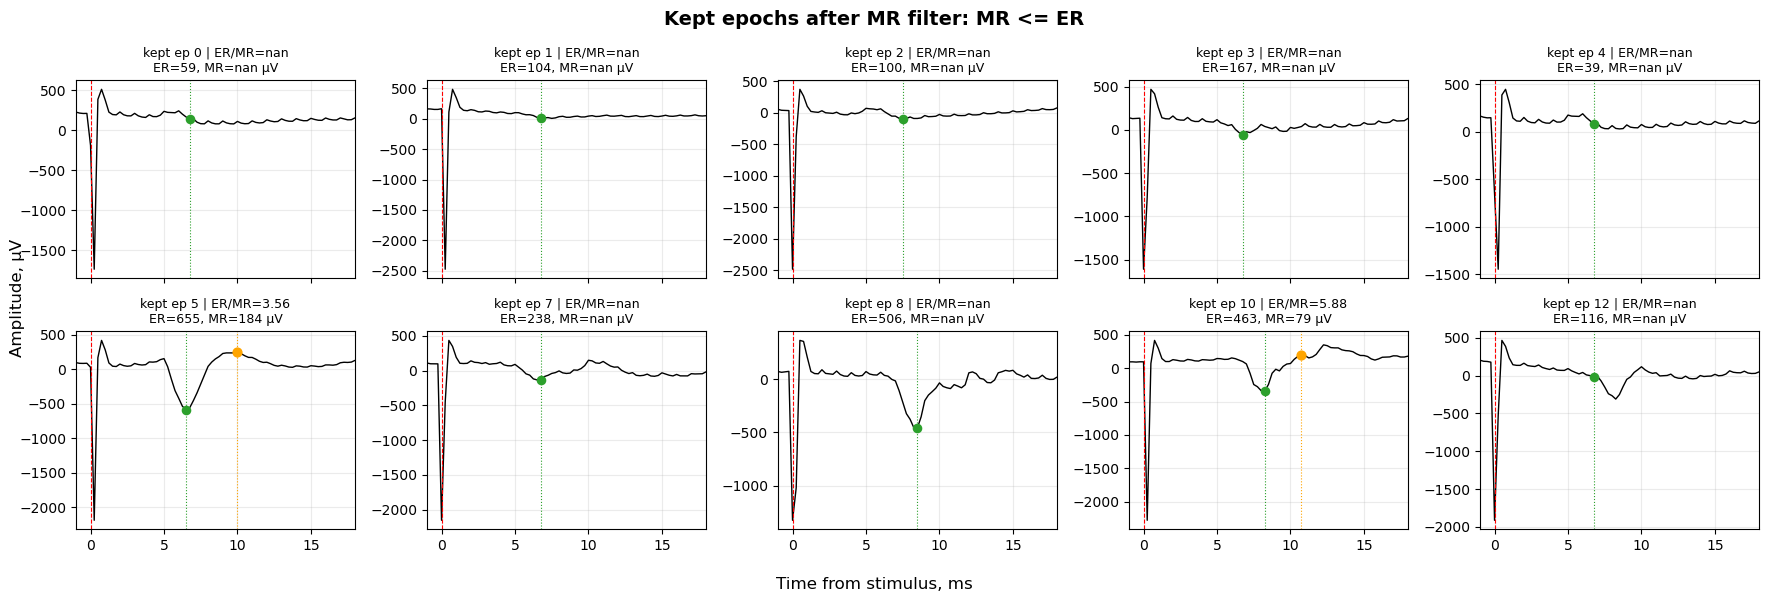

Shown kept epochs: [ 0  1  2  3  4  5  7  8 10 12]
Total kept: 344
Total rejected high MR: 895


In [48]:
# Визуальная проверка 10 эпох, прошедших MR-фильтр

assert "mr_filter_df" in globals(), "Сначала запусти ячейку с MR-фильтром"
assert "epochs_data_uv" in globals(), "Нужен epochs_data_uv"
assert "times_ms" in globals(), "Нужен times_ms"

check_indices = (
    mr_filter_df.loc[mr_filter_df["keep_after_mr"], "epoch_index"]
    .astype(int)
    .head(10)
    .to_numpy()
)

fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex=True)
axes = axes.ravel()

for ax, epoch_idx in zip(axes, check_indices):
    row = mr_filter_df.loc[mr_filter_df["epoch_index"] == epoch_idx].iloc[0]
    signal_uv = epochs_data_uv[epoch_idx]

    ax.plot(times_ms, signal_uv, color="black", lw=1)

    # Stimulus
    ax.axvline(0, color="red", ls="--", lw=0.8)

    # ER
    er_peak_ms = row.get("er_peak_ms", np.nan)
    if np.isfinite(er_peak_ms):
        er_i = np.argmin(np.abs(times_ms - er_peak_ms))
        ax.scatter(times_ms[er_i], signal_uv[er_i], color="tab:green", s=35, zorder=4)
        ax.axvline(er_peak_ms, color="tab:green", ls=":", lw=0.8)

    # MR
    mr_peak_ms = row.get("mr_peak_ms", np.nan)
    if np.isfinite(mr_peak_ms):
        mr_i = np.argmin(np.abs(times_ms - mr_peak_ms))
        ax.scatter(times_ms[mr_i], signal_uv[mr_i], color="orange", s=40, zorder=5)
        ax.axvline(mr_peak_ms, color="orange", ls=":", lw=0.8)

    ratio = row.get("er_mr_ratio", np.nan)
    ratio_txt = f"{ratio:.2f}" if np.isfinite(ratio) else "nan"

    ax.set_title(
        f"kept ep {epoch_idx} | ER/MR={ratio_txt}\n"
        f"ER={row.get('er_amp_for_mr_uv', np.nan):.0f}, "
        f"MR={row.get('mr_amp_uv', np.nan):.0f} µV",
        fontsize=9,
    )

    ax.set_xlim(-1, 18)
    ax.grid(alpha=0.25)

for ax in axes[len(check_indices):]:
    ax.axis("off")

fig.suptitle("Kept epochs after MR filter: MR <= ER", fontsize=14, weight="bold")
fig.supxlabel("Time from stimulus, ms")
fig.supylabel("Amplitude, µV")
plt.tight_layout()
plt.show()

print("Shown kept epochs:", check_indices)
print("Total kept:", int(mr_filter_df["keep_after_mr"].sum()))
print("Total rejected high MR:", int(mr_filter_df["reject_high_mr"].sum()))

In [ ]:
# 1. Находим индексы эпох, где есть И волна ER, И волна LR
valid_indices = []
for i, meta in enumerate(valid_meta):
    # Проверяем, что списки ER и LR внутри этой эпохи не пусты
    if meta['ER'] and meta['LR']:
        valid_indices.append(i)

print(f"🔍 Всего в записи найдено {len(valid_indices)} эпох, содержащих одновременно ER и LR.")

# 2. Берем первые 10 эпох (или сколько есть, если вдруг меньше 10)
indices_to_plot = valid_indices[:10]

if len(indices_to_plot) == 0:
    print("Не найдено ни одной эпохи, где одновременно размечены и ER, и LR. Проверьте названия меток.")
else:
    # 3. Строим сетку графиков 2x5 или сколько необходимо
    n_plots = len(indices_to_plot)
    ncols = 5
    nrows = int(np.ceil(n_plots / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows), sharex=True, sharey=True)
    axes = axes.flatten() if n_plots > 1 else [axes]
    
    # Получаем данные отфильтрованных эпох (для красивого гладкого отображения)
    epochs_data = epochs_filtered.get_data(picks=['GM R'])[:, 0, :]
    times_ms = epochs_filtered.times * 1000
    
    for plot_idx, epoch_idx in enumerate(indices_to_plot):
        ax = axes[plot_idx]
        signal = epochs_data[epoch_idx] * 1e6  # Переводим в мкВ
        
        ax.plot(times_ms, signal, color='black', lw=1.2, label='Signal')
        
        # Подсвечиваем зоны ER (зеленым) и LR (синим) прямо из вашей ручной разметки
        meta = valid_meta[epoch_idx]
        stim_onset = meta['onset']
        
        # Рисуем ER
        for er in meta['ER']:
            start_ms = (er['onset'] - stim_onset) * 1000
            end_ms = start_ms + (er['duration'] * 1000)
            ax.axvspan(start_ms, end_ms, color='green', alpha=0.2, label='ER' if plot_idx==0 else "")
            
        # Рисуем LR
        for lr in meta['LR']:
            start_ms = (lr['onset'] - stim_onset) * 1000
            end_ms = start_ms + (lr['duration'] * 1000)
            ax.axvspan(start_ms, end_ms, color='blue', alpha=0.2, label='LR' if plot_idx==0 else "")
            
        ax.grid(True, linestyle=':', alpha=0.5)
        
    # Удаляем пустые окошки, если эпох оказалось меньше, чем ячеек в сетке
    for j in range(plot_idx + 1, len(axes)):
        fig.delaxes(axes[j])
        
    # Добавляем общую легенду и подписи
    axes[0].legend(fontsize=8, loc='upper right')
    fig.text(0.5, 0.01, 'Time from Stimulus (ms)', ha='center', fontsize=11)
    fig.text(0.01, 0.5, r'Amplitude ($\mu$V)', va='center', rotation='vertical', fontsize=11)
    plt.suptitle("GM R Channel", fontsize=12, weight='bold', y=0.98)
    plt.tight_layout()
    plt.show()